In [1]:
# Import libraries
library(moments)
library(plyr)
library(sn)
library(stats)

Loading required package: stats4


Attaching package: 'sn'


The following object is masked from 'package:stats':

    sd




In [2]:
# Set the directory (please modify as required)
setwd('datasets')

In [3]:
# Download the dataset
data_set <- read.csv(file = "C:/Users/Yahya/Desktop/My folder/WQU/3. Financial Econometrics/Lessons/datasets/M3. bond_and_stock_data.csv", header=TRUE, stringsAsFactors = FALSE)

In [4]:
#########################################
# Figure 5: Key Statistics for U.S. 10-Year Treasury Bond Yield Daily Return
#########################################

mean(data_set$X10Y_TBY)
sd(data_set$X10Y_TBY)
skewness(data_set$X10Y_TBY)
kurtosis(data_set$X10Y_TBY)

[1] 0.0003751659

[1] 0.03616452

[1] 2.038126

[1] 42.72249

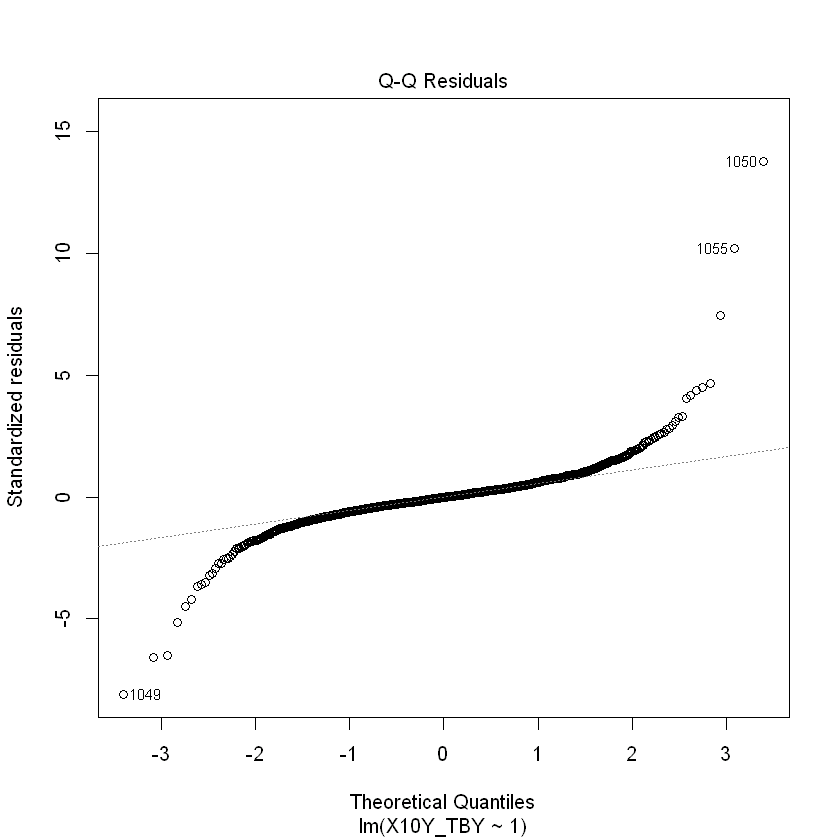

In [5]:
############################
# Figure 6: QQ Plot Normal Distribution vs U.S. 10-Year Treasury Bond Yield Daily Return
###########################

# Fit regular OLS
X10Y_nfit <- lm(X10Y_TBY ~ 1, data=data_set)

# QQ plot of residuals
plot(X10Y_nfit, which=2)

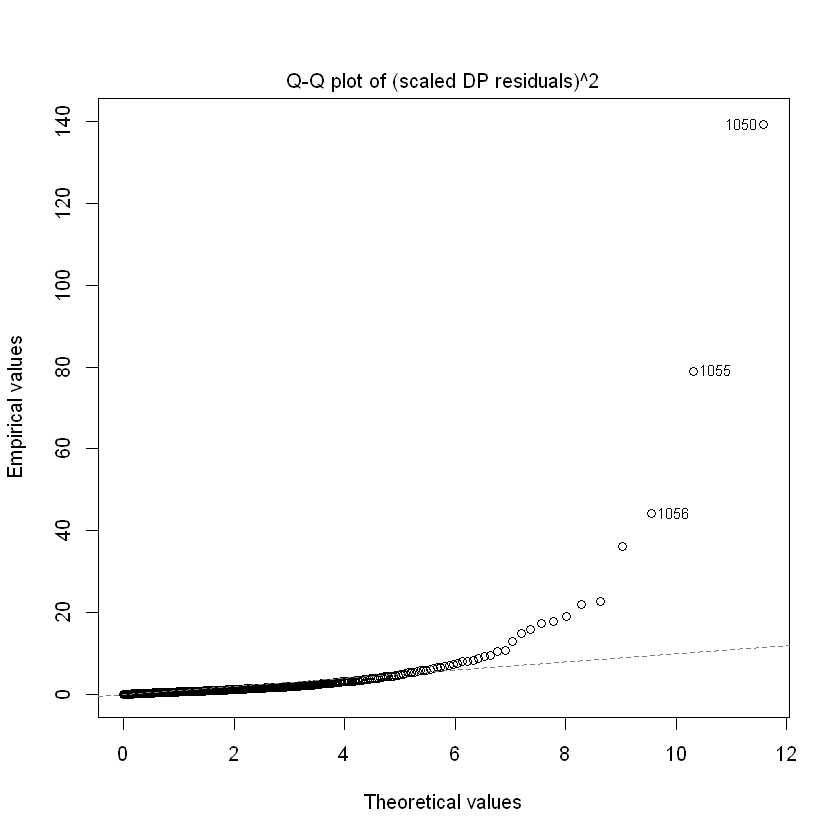

In [6]:
############################
# Figure 7: QQ Plot Skew-Normal Distribution vs U.S. Treasury 10-Year Bond Yield Daily Return
###########################

# Fit OLS with skew-Normal error terms
X10Y_snfit <- selm(X10Y_TBY ~ 1, data=data_set, family='SN')

# QQ plot of residuals
plot(X10Y_snfit, which=3, param.type='DP')

In [7]:
###############################
# Figure 8: Least Square Model Result
################################

# Fit regular OLS and print summary
ex_lm <- lm(X10Y_TBY ~ DWJ, data=data_set)
summary(ex_lm)


Call:
lm(formula = X10Y_TBY ~ DWJ, data = data_set)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.22532 -0.01422 -0.00128  0.01208  0.43982 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -0.0003206  0.0008533  -0.376    0.707    
DWJ          1.2157799  0.0709167  17.144   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.03309 on 1505 degrees of freedom
Multiple R-squared:  0.1634,	Adjusted R-squared:  0.1628 
F-statistic: 293.9 on 1 and 1505 DF,  p-value: < 2.2e-16


In [8]:
###############################
# Figure 9: Skew-Normal Regression Result
################################

# Fit OLS with skew normal error terms and print summary
ex_sn <- selm(X10Y_TBY ~ DWJ, data=data_set, family="SN")
summary(ex_sn, param.type='DP')

Call: selm(formula = X10Y_TBY ~ DWJ, family = "SN", data = data_set)
Number of observations: 1507 
Family: SN 
Estimation method: MLE
Log-likelihood: 3053.266 
Parameter type: DP 

DP residuals:
     Min       1Q   Median       3Q      Max 
-0.19895  0.01181  0.02482  0.03813  0.46436 

Regression coefficients
                 estimate    std.err    z-ratio Pr{>|z|}
(Intercept.DP)  -0.026387   0.001335 -19.768647        0
DWJ              1.247159   0.066077  18.874188        0

Parameters of the SEC random component
      estimate std.err
omega   0.0421   0.001
alpha   1.3602   0.091

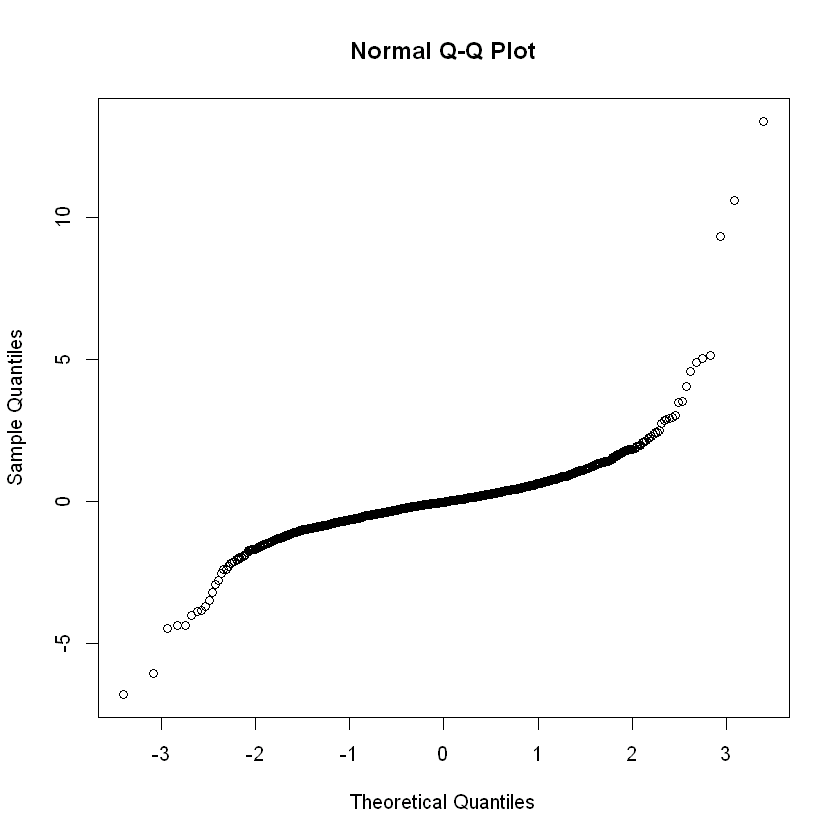

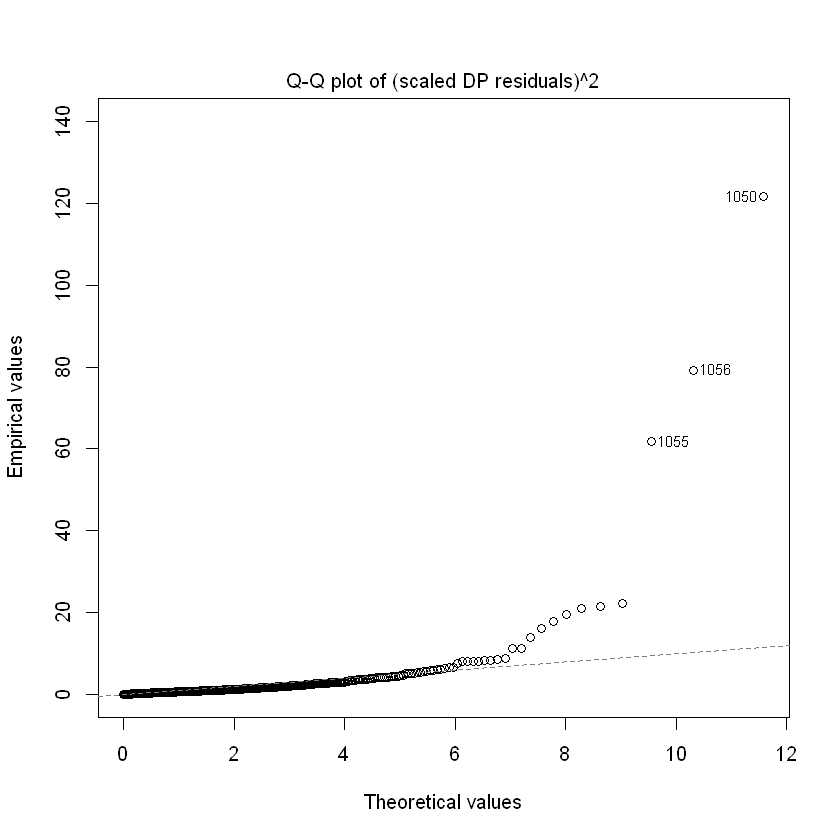

In [9]:
#########################################
# Figure 10: QQ Plots for Residuals from Normal Regression and for Residuals from Skew-Normal Regression
########################################

# QQ of residuals from regular regression
qqnorm(rstandard(ex_lm))

# QQ from skew-normal regression
plot(ex_sn, which=3)

In [10]:
##########################
# Figure 11: Simulated Skew-t Distributions with Different Degrees of Freedom
###########################

# skew t distribution with df=2000 almost infinity
set.seed(1234)
dpst1 <- cp2dp(c(25, 2, 0, 2000), family="ST")
st1 <- rst(3000, dp=dpst1)

# skew t distribution with df=6
set.seed(1234)
dpst2 <- cp2dp(c(25, 2, 0, 6), family="ST")
st2 <- rst(3000, dp=dpst2)

# skew t distribution with df=4
set.seed(1234)
dpst3 <- cp2dp(c(25, 2, 0, 4), family="ST")
st3 <- rst(3000, dp=dpst3)

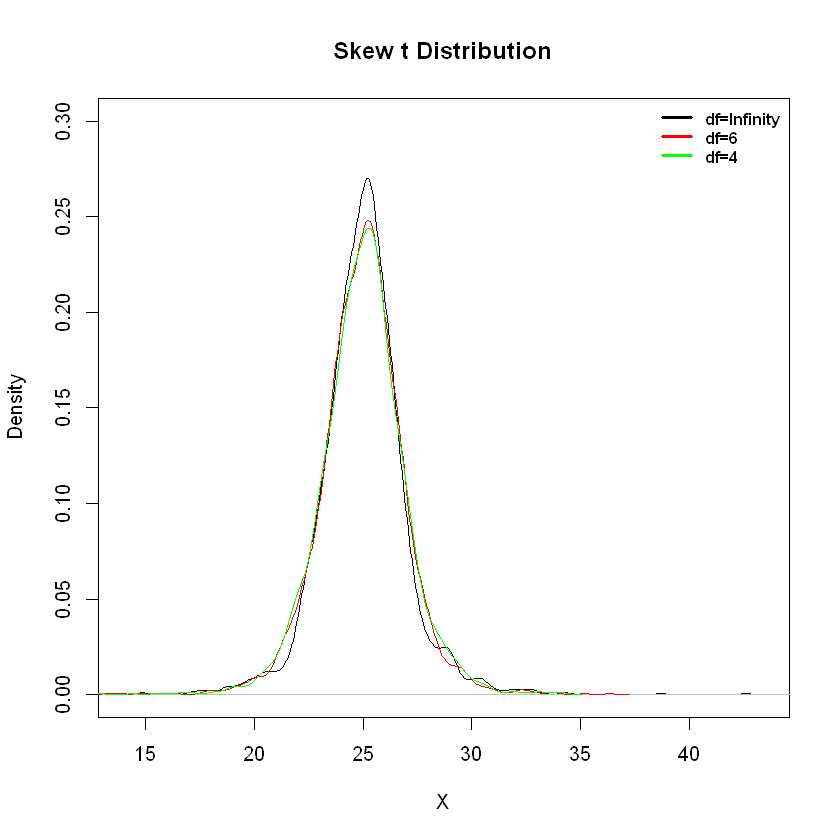

In [11]:
# Plot 3 skew t distributions
plot(density(st1), xlab="X", ylim=c(0,0.3), main="Skew t Distribution")
lines(density(st2), col='red')
lines(density(st3), col='green')
legend("topright", inset=c(-0.005,0),  c("df=Infinity", "df=6", "df=4"),
       lty=rep(1, 3), bty="n", col=c("black","red","green"),
       pt.cex=1, cex=0.8, text.font=2, lwd=3)

Warning message in st.infoUv(dp = fit$dp, NULL, x, yInfo, w, fixed.nu, symmetr, :
"'dp' does not seem to be at MLE; score not quite 0"


score(dp):  9.208508 -45.31995 -37.66498 -11.43076 
norm(score)^2: 19.1973 


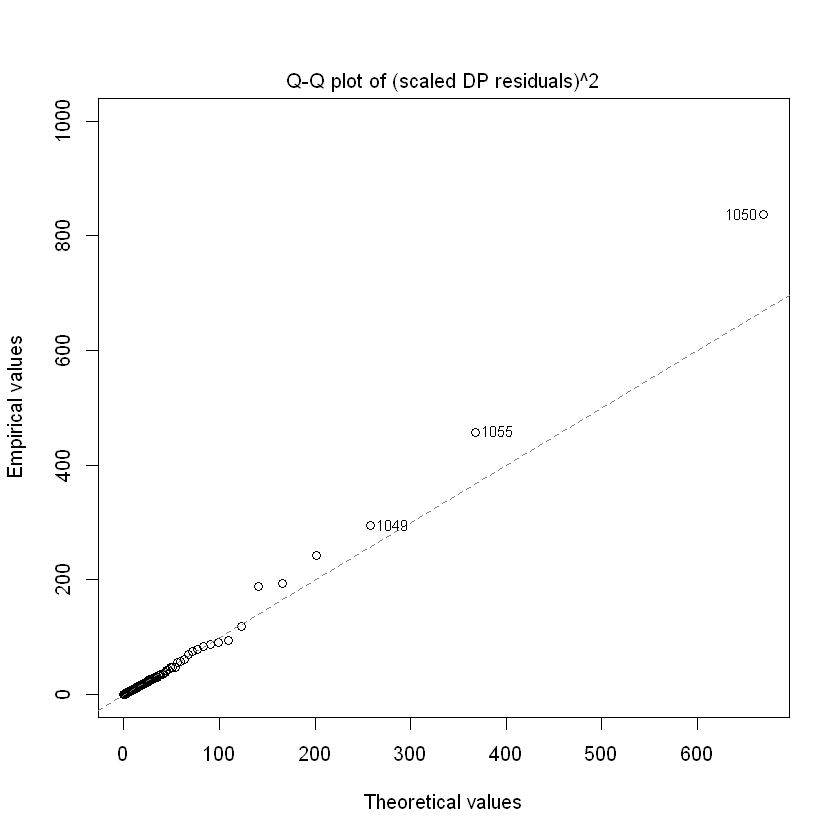

In [12]:
##########################
# Figure 12: QQ Plot Skew-t Distribution vs. U.S. Treasury 10-Year Bond Yield Daily Return
###########################

# Fit OLS with skew t error terms
X10Y_stfit <- selm(X10Y_TBY ~ 1, data=data_set, family='ST')

# QQ plot of residuals
plot(X10Y_stfit, which=3, param.type='DP')

In [13]:
##########################
# Figure 13: Skew-t Distribution Regression Result
###########################

# Fit OLS with skew t error terms and print summary
ex_st <- selm(X10Y_TBY ~ DWJ, data=data_set, family="ST")
summary(ex_st, param.type='DP')

Warning message in st.infoUv(dp = fit$dp, NULL, x, yInfo, w, fixed.nu, symmetr, :
"'dp' does not seem to be at MLE; score not quite 0"


score(dp):  6.820474 6.350668 27.74207 9.909683 -23.59609 
norm(score)^2: 13.41224 


Call: selm(formula = X10Y_TBY ~ DWJ, family = "ST", data = data_set)
Number of observations: 1507 
Family: ST 
Estimation method: MLE
Log-likelihood: 3417.059 
Parameter type: DP 

DP residuals:
      Min        1Q    Median        3Q       Max 
-0.222359 -0.009982  0.002732  0.016315  0.449093 

Regression coefficients
                estimate   std.err   z-ratio Pr{>|z|}
(Intercept.DP) -0.004337  0.001598 -2.714837    0.007
DWJ             1.108454  0.079238 13.988900    0.000

Parameters of the SEC random component
      estimate std.err
omega  0.01611   0.001
alpha  0.21008   0.109
nu     2.24983   0.153

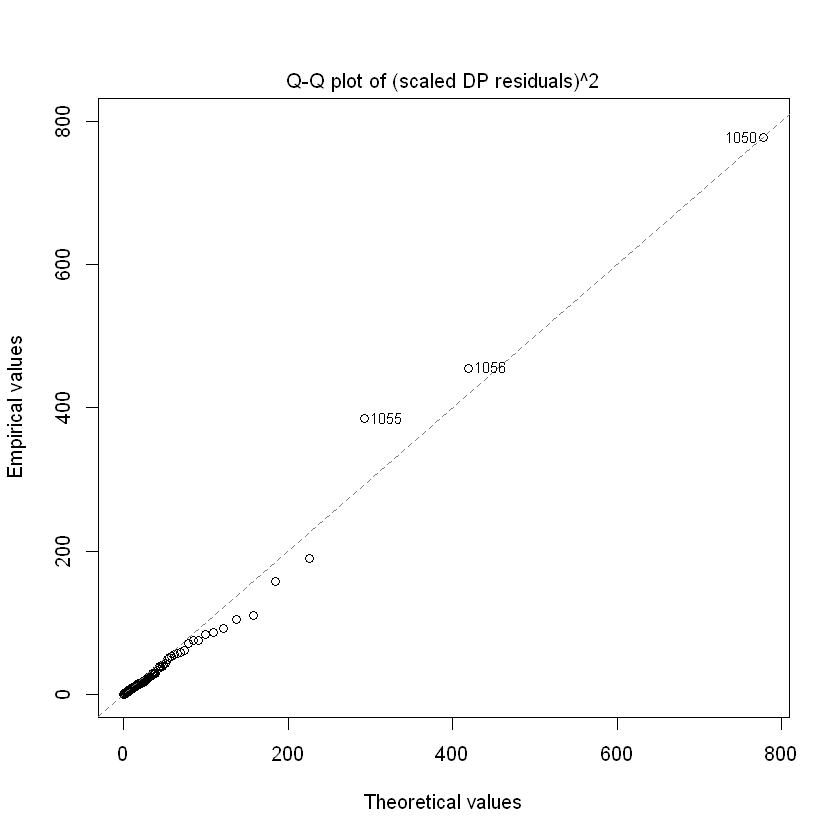

In [14]:
##########################
# Figure 14: QQ Plots for Residuals from Skew-Normal Regression and for Residuals from Skew-t Regression
###########################

plot(ex_st, which=3, param.type='DP')